## Análise Exploratória de Dados

In [1]:
#Importações
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from Apoio.config import DADOS_CONSOLIDADOS, DADOS_TRATADOS

sns.set_theme(palette="bright")

#### Importação da base e checagens básicas

In [2]:
df = pd.read_parquet(DADOS_CONSOLIDADOS)

df.head()

,ano_modelo,marca,modelo,classe_veiculo,tamanho_motor_l,cilindros,transmissao,tipo_combustivel,consumo_cidade_l_100km,consumo_estrada_l_100km,consumo_combinado_l_100km,consumo_combinado_mpg,emissoes_co2_g_km,classificacao_co2,classificacao_smog
0,2005,Acura,1.7EL,Compact,1.7,4,A4,X,9.2,7.2,8.3,34,191,NaN,NaN
1,2005,Acura,1.7EL,Compact,1.7,4,M5,X,9.1,7.3,8.3,34,191,NaN,NaN
2,2005,Acura,MDX AWD,Sport utility vehicle,3.5,6,A5,Z,15.9,11.1,13.7,21,315,NaN,NaN
3,2005,Acura,NSX,Two-seater,3.0,6,AS4,Z,15.1,10.5,13.0,22,299,NaN,NaN
4,2005,Acura,NSX,Two-seater,3.2,6,M6,Z,15.1,10.5,13.0,22,299,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20521 entries, 0 to 20520
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ano_modelo                 20521 non-null  int64  
 1   marca                      20521 non-null  object 
 2   modelo                     20521 non-null  object 
 3   classe_veiculo             20521 non-null  object 
 4   tamanho_motor_l            20521 non-null  float64
 5   cilindros                  20521 non-null  int64  
 6   transmissao                20521 non-null  object 
 7   tipo_combustivel           20521 non-null  object 
 8   consumo_cidade_l_100km     20521 non-null  float64
 9   consumo_estrada_l_100km    20521 non-null  float64
 10  consumo_combinado_l_100km  20521 non-null  float64
 11  consumo_combinado_mpg      20521 non-null  int64  
 12  emissoes_co2_g_km          20521 non-null  int64  
 13  classificacao_co2          8832 non-null   flo

In [4]:
with pd.option_context("display.float_format", "{:.2f}".format):
    display(df.describe())

,ano_modelo,tamanho_motor_l,cilindros,consumo_cidade_l_100km,consumo_estrada_l_100km,consumo_combinado_l_100km,consumo_combinado_mpg,emissoes_co2_g_km,classificacao_co2,classificacao_smog
count,20521.00,20521.00,20521.00,20521.00,20521.00,20521.00,20521.00,20521.00,8832.00,7726.00
mean,2014.24,3.34,5.83,13.44,9.72,11.76,25.74,266.81,4.63,4.82
std,5.59,1.35,1.87,3.78,2.52,3.18,7.02,63.51,1.58,1.79
min,2005.00,0.80,2.00,4.00,3.90,4.00,11.00,94.00,1.00,1.00
25%,2009.00,2.20,4.00,10.80,8.00,9.60,21.00,221.00,4.00,3.00
50%,2014.00,3.00,6.00,13.00,9.30,11.30,25.00,262.00,5.00,5.00
75%,2019.00,4.00,8.00,15.50,11.00,13.40,29.00,304.00,5.00,6.00
max,2024.00,8.40,16.00,30.70,22.10,26.10,71.00,608.00,10.00,8.00


In [5]:
df.describe(exclude="number")

,marca,modelo,classe_veiculo,transmissao,tipo_combustivel
count,20521,20521,20521,20521,20521
unique,48,3522,17,29,5
top,Chevrolet,Mustang,Mid-size,AS6,X
freq,1884,96,2736,2876,10179


#### Criando uma nova coluna para o número de marchas e eliminando da coluna de transmissão

In [6]:
df["marchas"] = df["transmissao"].str.extract(r"(\d+)").astype("float")
df["transmissao"] = df["transmissao"].str.replace(r"(\d+)", "", regex=True)

df.head()

,ano_modelo,marca,modelo,classe_veiculo,tamanho_motor_l,cilindros,transmissao,tipo_combustivel,consumo_cidade_l_100km,consumo_estrada_l_100km,consumo_combinado_l_100km,consumo_combinado_mpg,emissoes_co2_g_km,classificacao_co2,classificacao_smog,marchas
0,2005,Acura,1.7EL,Compact,1.7,4,A,X,9.2,7.2,8.3,34,191,NaN,NaN,4.0
1,2005,Acura,1.7EL,Compact,1.7,4,M,X,9.1,7.3,8.3,34,191,NaN,NaN,5.0
2,2005,Acura,MDX AWD,Sport utility vehicle,3.5,6,A,Z,15.9,11.1,13.7,21,315,NaN,NaN,5.0
3,2005,Acura,NSX,Two-seater,3.0,6,AS,Z,15.1,10.5,13.0,22,299,NaN,NaN,4.0
4,2005,Acura,NSX,Two-seater,3.2,6,M,Z,15.1,10.5,13.0,22,299,NaN,NaN,6.0


#### Substituindo a informação de tipo_combustivel por seu significado

In [7]:
comb = {
    "X": "gasolina_regular",
    "Z": "gasolina_premium",
    "D": "diesel",
    "E": "etanol",
    "N": "gas_natural"
}

df["tipo_combustivel"] = df["tipo_combustivel"].map(comb)

df.head()

,ano_modelo,marca,modelo,classe_veiculo,tamanho_motor_l,cilindros,transmissao,tipo_combustivel,consumo_cidade_l_100km,consumo_estrada_l_100km,consumo_combinado_l_100km,consumo_combinado_mpg,emissoes_co2_g_km,classificacao_co2,classificacao_smog,marchas
0,2005,Acura,1.7EL,Compact,1.7,4,A,gasolina_regular,9.2,7.2,8.3,34,191,NaN,NaN,4.0
1,2005,Acura,1.7EL,Compact,1.7,4,M,gasolina_regular,9.1,7.3,8.3,34,191,NaN,NaN,5.0
2,2005,Acura,MDX AWD,Sport utility vehicle,3.5,6,A,gasolina_premium,15.9,11.1,13.7,21,315,NaN,NaN,5.0
3,2005,Acura,NSX,Two-seater,3.0,6,AS,gasolina_premium,15.1,10.5,13.0,22,299,NaN,NaN,4.0
4,2005,Acura,NSX,Two-seater,3.2,6,M,gasolina_premium,15.1,10.5,13.0,22,299,NaN,NaN,6.0


#### Verificando se há colunas com valores zeros, nulos ou duplicados

In [8]:
df[df == 0].count()

ano_modelo                   0
marca                        0
modelo                       0
classe_veiculo               0
tamanho_motor_l              0
cilindros                    0
transmissao                  0
tipo_combustivel             0
consumo_cidade_l_100km       0
consumo_estrada_l_100km      0
consumo_combinado_l_100km    0
consumo_combinado_mpg        0
emissoes_co2_g_km            0
classificacao_co2            0
classificacao_smog           0
marchas                      0
dtype: int64

In [9]:
df.isnull().sum()

ano_modelo                       0
marca                            0
modelo                           0
classe_veiculo                   0
tamanho_motor_l                  0
cilindros                        0
transmissao                      0
tipo_combustivel                 0
consumo_cidade_l_100km           0
consumo_estrada_l_100km          0
consumo_combinado_l_100km        0
consumo_combinado_mpg            0
emissoes_co2_g_km                0
classificacao_co2            11689
classificacao_smog           12795
marchas                        864
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

Com isso, podemos observar que as colunas de **"classificacao_co2"**, **"classificacao_smog"** e **"marchas"** possuem valores nulos

| Coluna                        | Quantidade                  |
| ----------------------------- | --------------------------- |
| `classificacao_co2`           | `11689`                     |
| `classificacao_smog`          | `12795`                     |
| `marchas`                     | `864`                       |

#### Eliminando as colunas "consumo_combinado_mpg" e "modelo"

A coluna **consumo_combinado_mpg** é a **consumo_combinado_l_100km**, mas convertida para milhas.

Já a coluna **modelo** deve ser eliminada, pois possui `3522` valores únicos e isso pode atrapalhar o algortimo na identificação de valores que só aparecem apenas uma vez.

In [11]:
df = df.drop(columns=["consumo_combinado_mpg", "modelo"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20521 entries, 0 to 20520
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ano_modelo                 20521 non-null  int64  
 1   marca                      20521 non-null  object 
 2   classe_veiculo             20521 non-null  object 
 3   tamanho_motor_l            20521 non-null  float64
 4   cilindros                  20521 non-null  int64  
 5   transmissao                20521 non-null  object 
 6   tipo_combustivel           20521 non-null  object 
 7   consumo_cidade_l_100km     20521 non-null  float64
 8   consumo_estrada_l_100km    20521 non-null  float64
 9   consumo_combinado_l_100km  20521 non-null  float64
 10  emissoes_co2_g_km          20521 non-null  int64  
 11  classificacao_co2          8832 non-null   float64
 12  classificacao_smog         7726 non-null   float64
 13  marchas                    19657 non-null  flo

In [12]:
df.nunique()

ano_modelo                    20
marca                         48
classe_veiculo                17
tamanho_motor_l               61
cilindros                      9
transmissao                    5
tipo_combustivel               5
consumo_cidade_l_100km       237
consumo_estrada_l_100km      168
consumo_combinado_l_100km    207
emissoes_co2_g_km            374
classificacao_co2             10
classificacao_smog             7
marchas                        8
dtype: int64

#### Criando uma lista de colunas categóricas, para visualização

In [16]:
categoricas = df.select_dtypes(include="object").columns
categoricas = categoricas.to_list()
categoricas.extend(["ano_modelo", "cilindros", "marchas"])
categoricas

['marca',
 'classe_veiculo',
 'transmissao',
 'tipo_combustivel',
 'ano_modelo',
 'cilindros',
 'marchas']

As colunas **ano_modelo**, **cilindros** e **marchas** foram adicionadas, pois possuem caráter categórico.

#### Gráfico de contagem das colunas categóricas

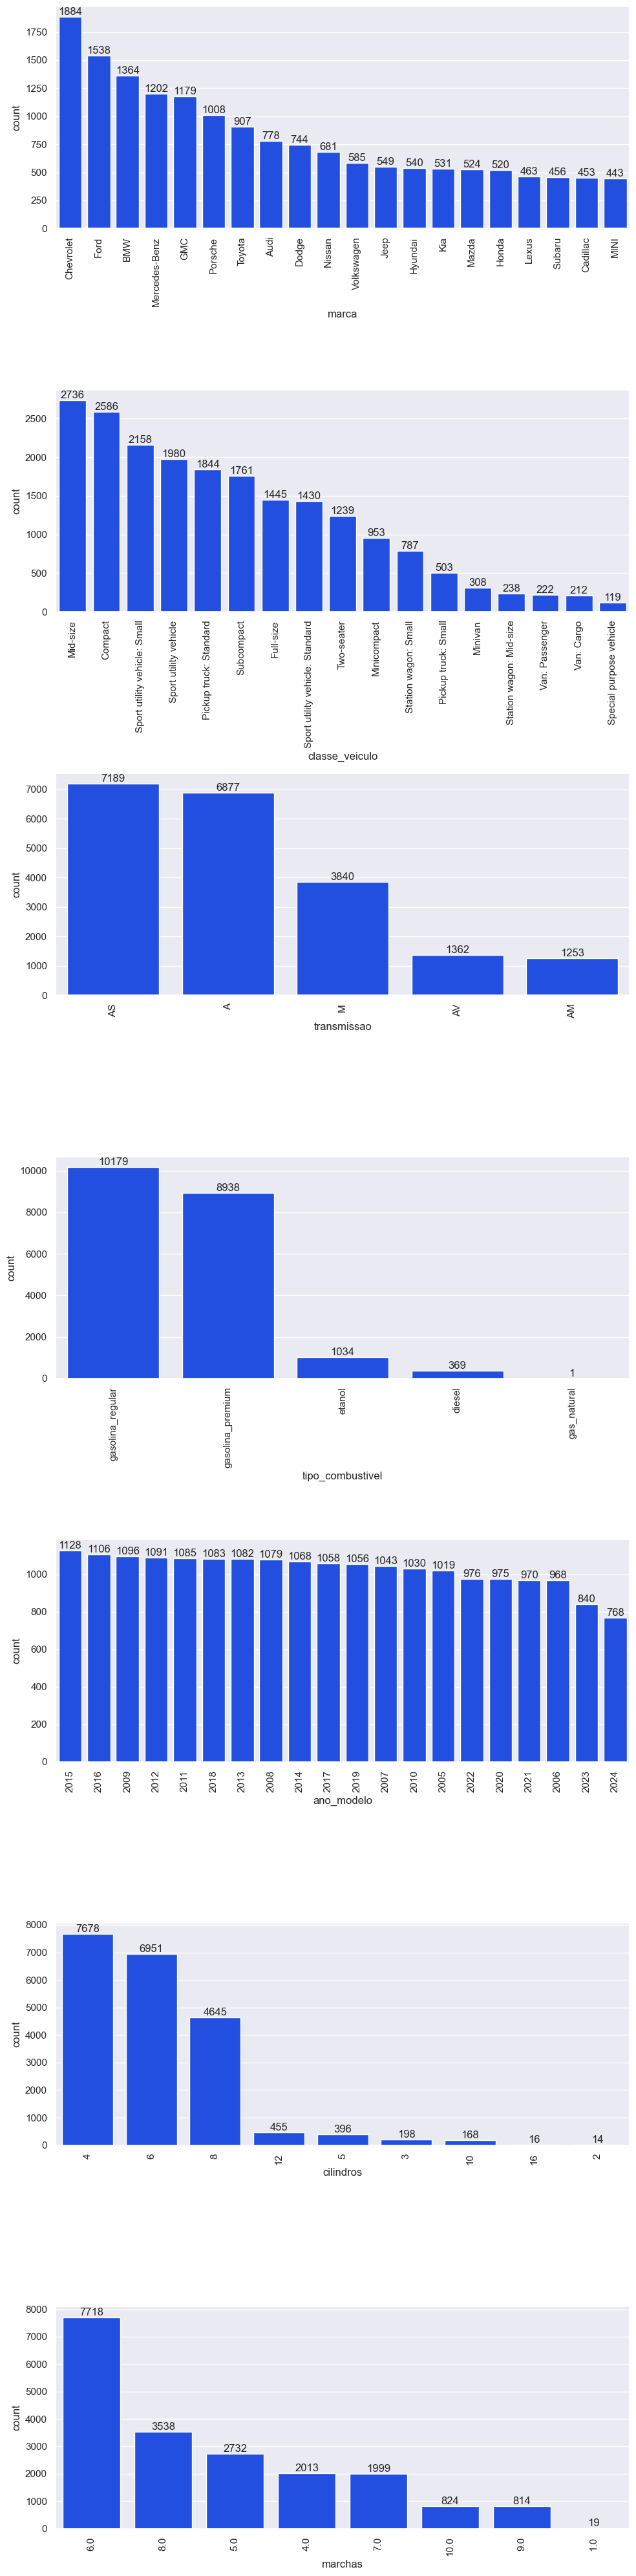

In [47]:
fig, axs = plt.subplots(7, 1, figsize=(10, 40))

for ax, coluna in zip(axs.flatten(), categoricas):
    sns.countplot(data=df, x=coluna, ax=ax, order=df[coluna].value_counts().index[:20])
    
    ax.bar_label(ax.containers[0])
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

#### Criando um crosstab entre as colunas de marcha e transmissão, para verificar a frequência e relação entre elas

In [43]:
pd.crosstab(df["marchas"], df["transmissao"], dropna=False)

transmissao,A,AM,AS,AV,M
marchas,,,,,
1.0,0,0,0,19,0
4.0,1850,0,162,0,1
5.0,889,6,673,0,1164
6.0,1944,215,2876,159,2524
7.0,276,794,621,157,151
8.0,989,232,2193,124,0
9.0,650,6,158,0,0
10.0,279,0,506,39,0
NaN,0,0,0,864,0


#### Criando os histogramas e boxplots das colunas numéricas

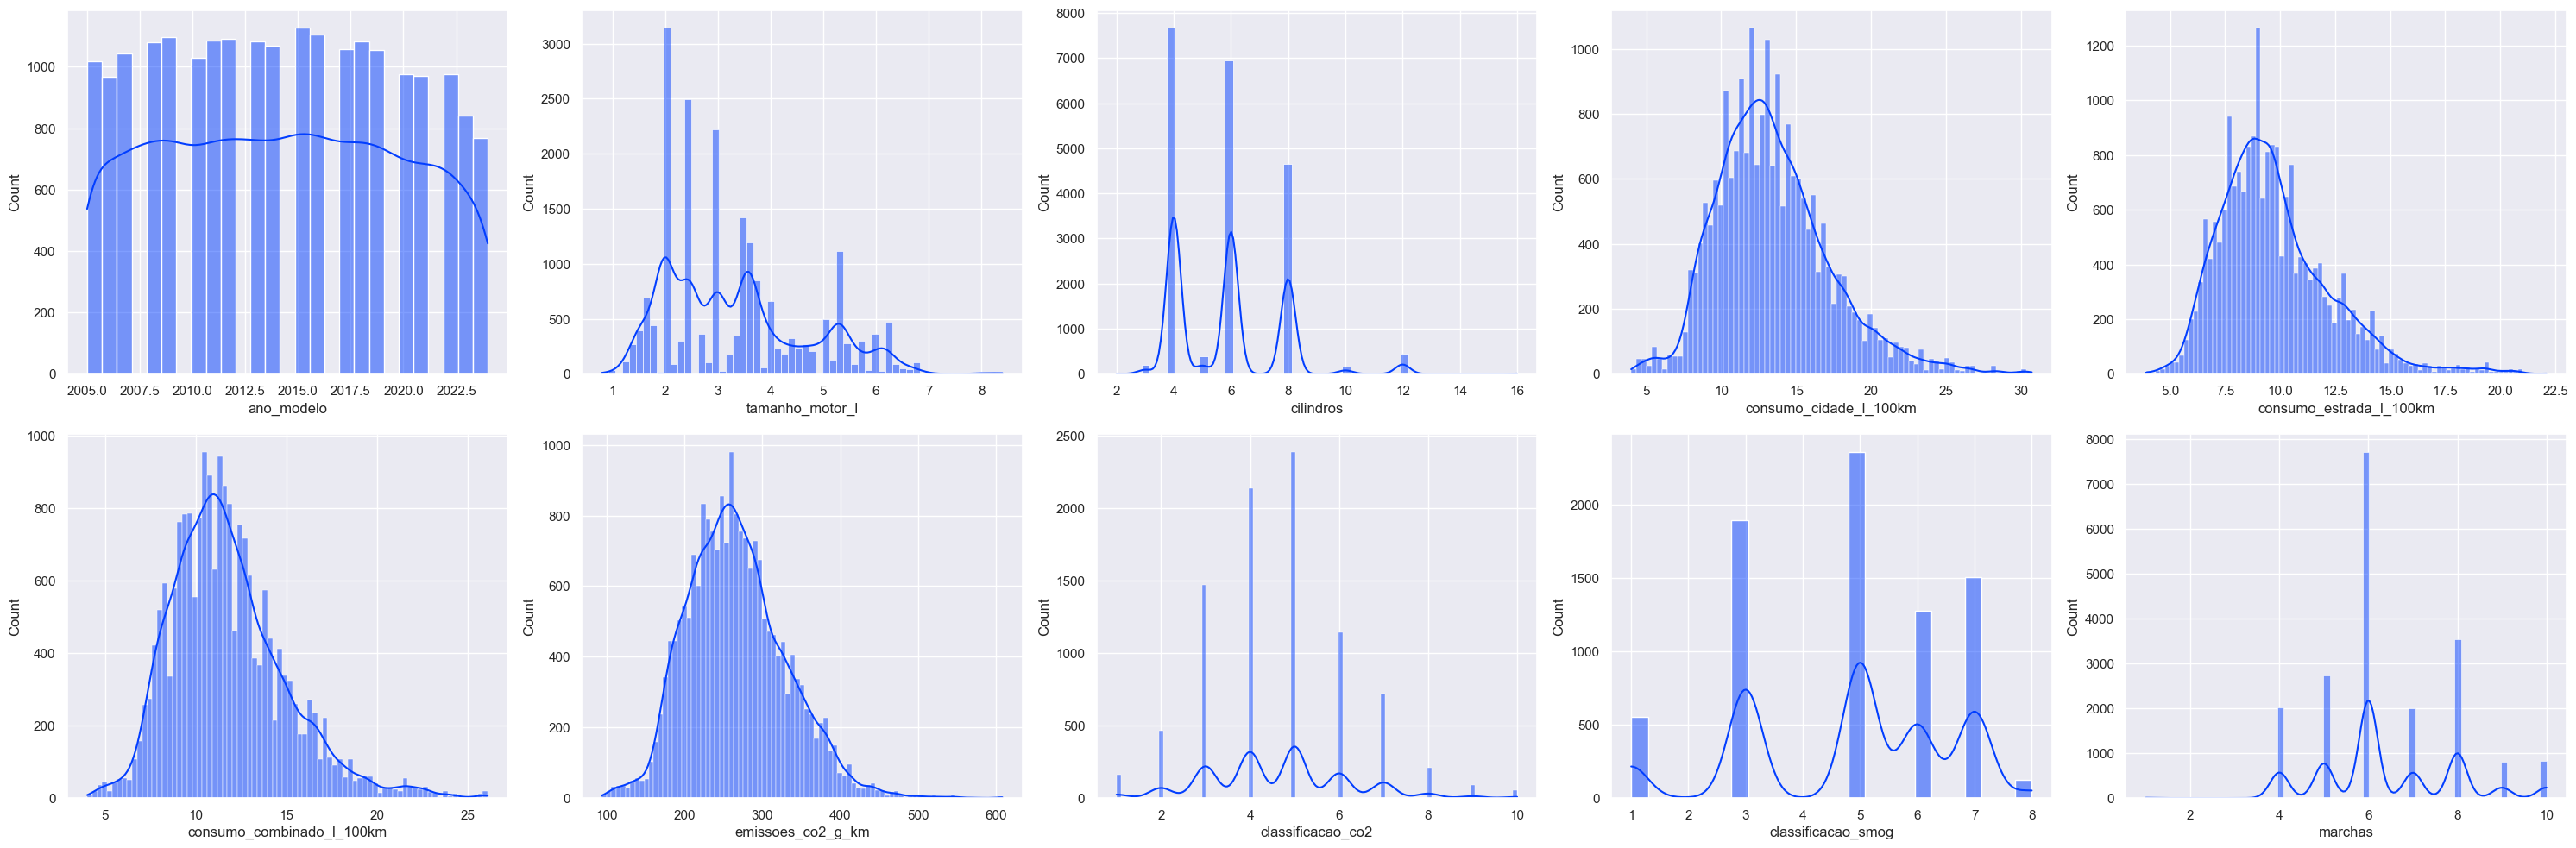

In [53]:
fig, axs = plt.subplots(2, 5, figsize=(30, 10))

for ax, coluna in zip(axs.flatten(), df.select_dtypes("number").columns):
    sns.histplot(data=df, x=coluna, ax=ax, kde=True)

plt.tight_layout()
plt.show()

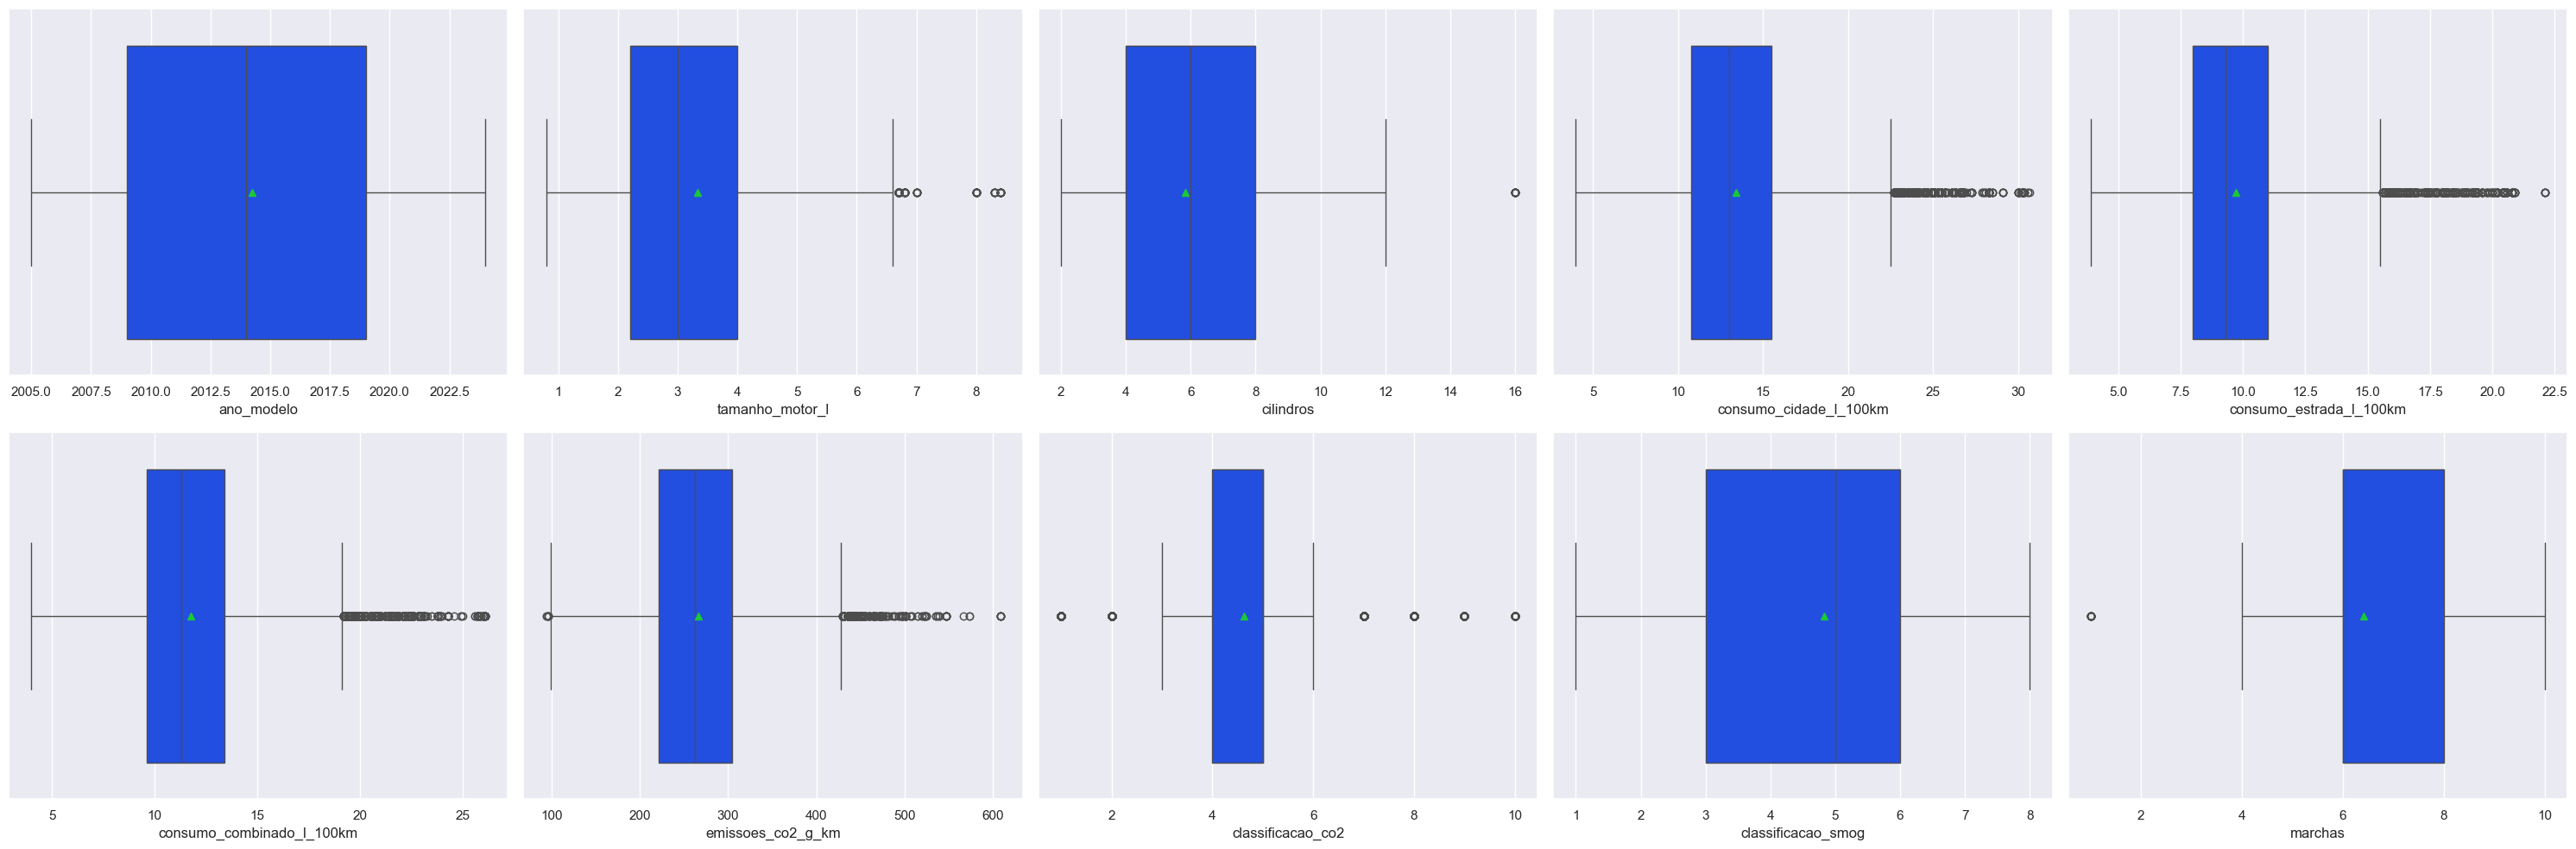

In [54]:
fig, axs = plt.subplots(2, 5, figsize=(30, 10))

for ax, coluna in zip(axs.flatten(), df.select_dtypes("number").columns):
    sns.boxplot(data=df, x=coluna, ax=ax, showmeans=True)

plt.tight_layout()
plt.show()

- crie a correlação, matriz e mapa de calor das colunas numéricas
- Crie um gráfico de barras do dataframe de 'make' por 'emissão de co2 g/km', usando um groupby dos mesmos filtrados por média e ordenados com ascending False e o index (tudo como order). Depois, crie as anotações das barras, retire rótulos, coloque título e organize a escala de cores
- repita o processo anterior, mas usando classe de veículos e emissão de co2 por g/km
- repita isso, mas com o tipo de combustível
- repita isso com ano do modelo
- faça um crosstab do ano do modelo pela classe do veículo
- repita isso, mas substitua a classe pelo tipo d combustível
- verifique e apague a coluna com gás natural como tipo de combustível
- repita o crosstab anterior usando um gradiente de cores "coolwarm"
- repita o crosstab anterior com values de emissão de co2 por g/km, usando aggfunc mean, um gradiente de cores e axis None
- faça uma figura com 2 histogramas, um para "city_l_100_km" e um para "highway_l_100_km"
- faça um gráfico de dispersão de combined_l_100_km por co2_emissions_g_km, usando o tipo de combustível como hue
- repita o anterior, mas usando o hue "transmission"
- repita o processo do primeiro gráfico de disperão usando x sendo engine_size_l
- repita o primeiro, mas usando a classe de veículos como hue, ajuste uma legenda
- Crie um dicionário com as classes dos carros, fazendo uma divisão (pode pegar a que o professor fez), depois atribua para uma coluna nova "vehicle_class_grouped"
- repita o anterior, mas usando essa nova coluna como hue
- faça um crosstab dessa nova coluna pelo tipo de combustível
- tire as colunas que serão desnecessárias para a próxima etapa do projeto ("make", "co2_rating", "smog_rating", "gears", "vehicle_class")
- faça um pairplot do dataframe usando "reg" como kind, apareca kde e utilizando plot_kws={"line_kws": {"color": "red"}, "scatter_kws": {"alpha": 0.25}}
- verifique a contagem de valores da coluna "engine_size_l" com 4 bins, ordenados pelo index
- aplique um cut do pandas na coluna "engine_size_l" com os seguintes bins -np.inf, 2.0, 4.0, 6.0, np.inf, depois edite os labels para "up_to_2", "up_to_4", "up_to_6", "more_than_6"
- faça a mesma coisa, mas para a coluna de classe de cilindros. Use -np.inf, 4, 6, 8, np.inf e adapte os labels com base no anterior
- remova as colunas engine_size_l", "cylinders e depois faça o .info()
- exporte para tipo parquet
